In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/24pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.147692
2014-07-04 22:00:00,0.559069,0.308571
2014-07-04 23:00:00,0.613930,0.351226
2014-07-05 00:00:00,0.745596,0.449565
2014-07-05 01:00:00,0.789484,0.368602


In [4]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/24pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.128463
2014-07-04 22:00:00,0.559069,0.241268
2014-07-04 23:00:00,0.613930,0.314786
2014-07-05 00:00:00,0.745596,0.348594
2014-07-05 01:00:00,0.789484,0.179847


In [5]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/24pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,-0.159769
2014-07-04 22:00:00,0.559069,-0.044846
2014-07-04 23:00:00,0.613930,0.036686
2014-07-05 00:00:00,0.745596,0.102364
2014-07-05 01:00:00,0.789484,0.126591


In [6]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.009063
2014-07-04 22:00:00,0.559069,0.219173
2014-07-04 23:00:00,0.613930,0.344451
2014-07-05 00:00:00,0.745596,0.561541
2014-07-05 01:00:00,0.789484,0.531499


In [7]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)
datosI.index = datosCross.index
datosI.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.855610
2014-07-04 22:00:00,0.559069,0.856116
2014-07-04 23:00:00,0.613930,0.992877
2014-07-05 00:00:00,0.745596,0.993342
2014-07-05 01:00:00,0.789484,0.813371


In [8]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 4468 - 4337 - 21
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,-0.053353
2014-07-04 22:00:00,0.559069,0.026601
2014-07-04 23:00:00,0.613930,0.083297
2014-07-05 00:00:00,0.745596,0.118325
2014-07-05 01:00:00,0.789484,-0.041917


## MLP ##

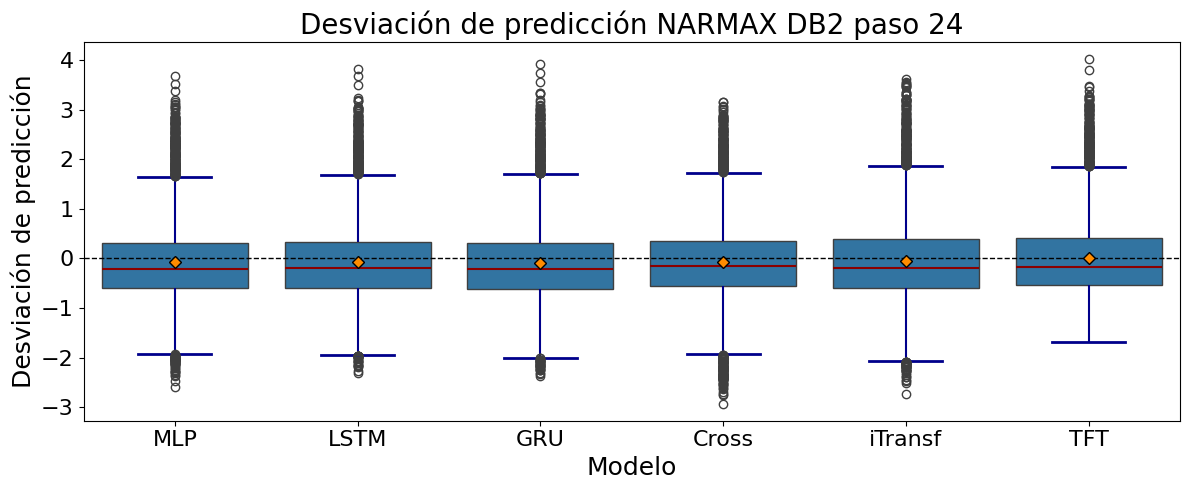

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción NARMAX DB2 paso 24', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda


plt.tight_layout()
plt.show()


# Graficos Q-Q

In [10]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-07-04 21:00:00,0.641793,0.661022,0.949253,0.780421,-0.066125,0.842837
2014-07-04 22:00:00,0.250498,0.317800,0.603915,0.339895,-0.297047,0.532467
2014-07-04 23:00:00,0.262703,0.299143,0.577243,0.269479,-0.378947,0.530633
2014-07-05 00:00:00,0.296031,0.397001,0.643232,0.184054,-0.247747,0.627271
2014-07-05 01:00:00,0.420883,0.609637,0.662893,0.257985,-0.023887,0.831402


In [11]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [12]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-08-18 14:00:00,0.190047,0.166431,0.094643,0.240910,0.068268,0.068951
2014-08-09 13:00:00,-0.027653,-0.081478,-0.069502,0.020206,-0.066608,-0.057016
2014-08-24 19:00:00,-0.917007,-0.773765,-0.654005,-0.707186,-0.953434,-0.705271
2014-11-23 21:00:00,0.497262,0.546998,0.436793,0.375779,0.356734,0.277868
2014-10-06 15:00:00,-0.463247,-0.378396,-0.552480,-0.307945,-0.193792,-0.339849


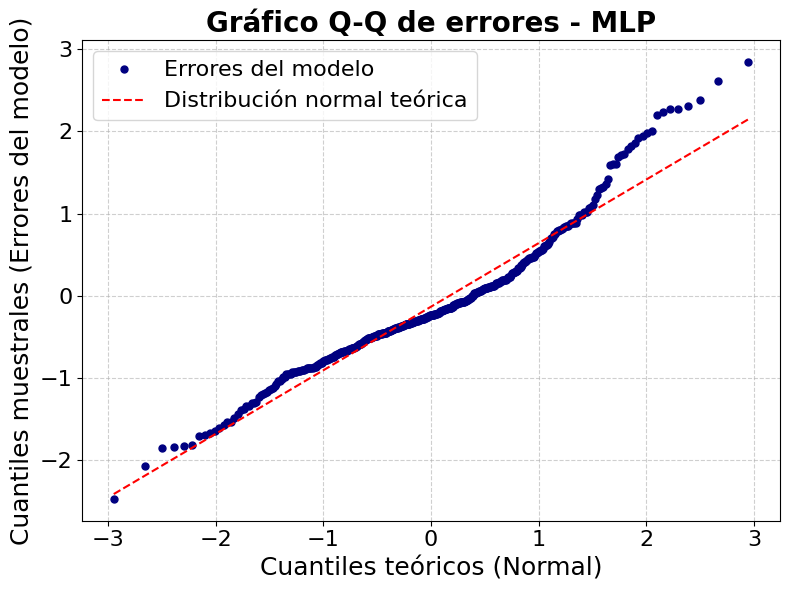

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


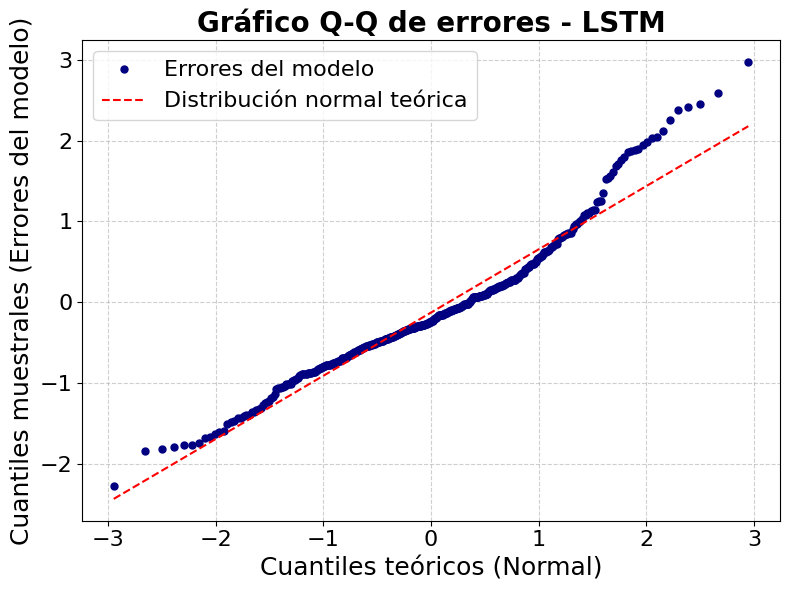

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


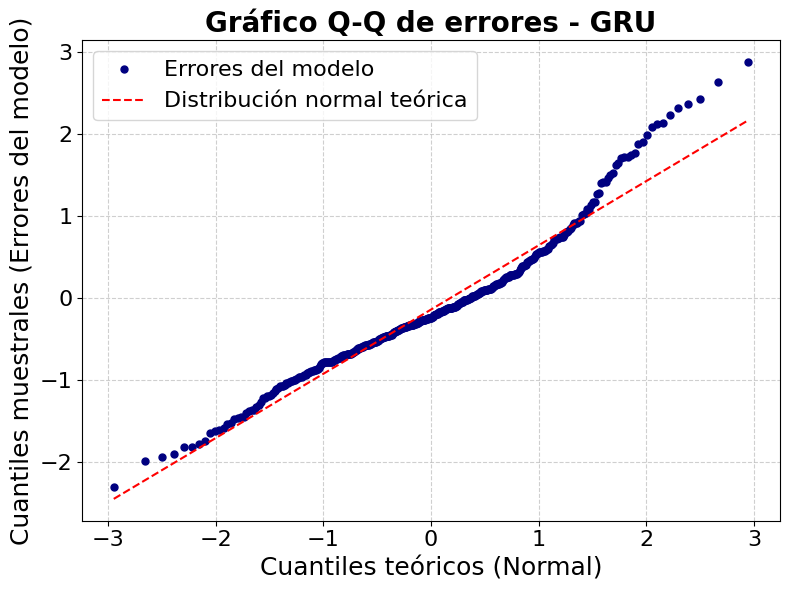

In [15]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


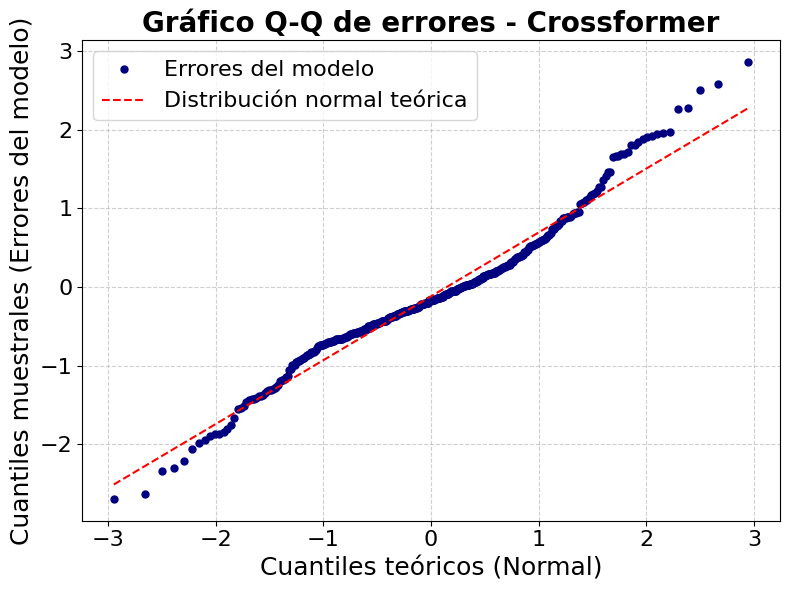

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


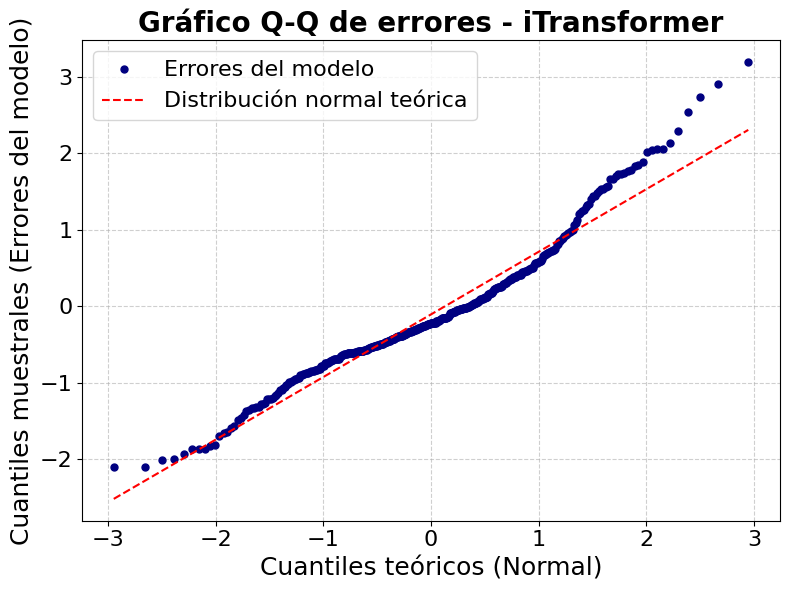

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


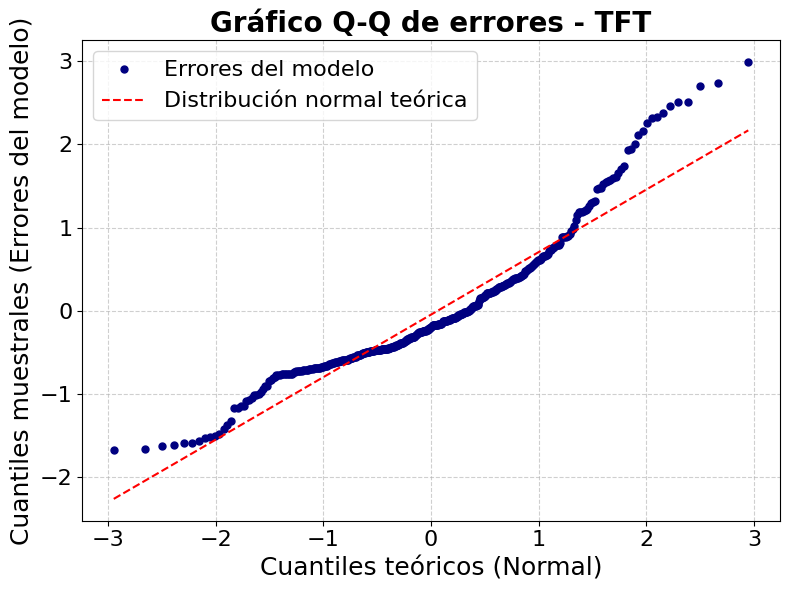

In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

meses = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
def formatear_mes(x, pos):
    fecha = mdates.num2date(x)
    return meses.get(fecha.month, '')

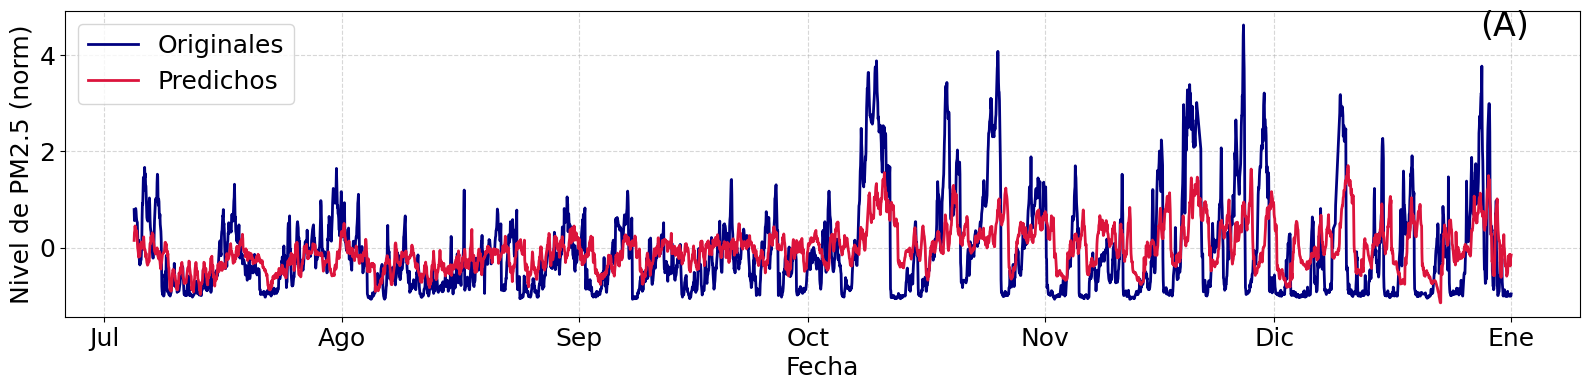

In [20]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosMLP

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


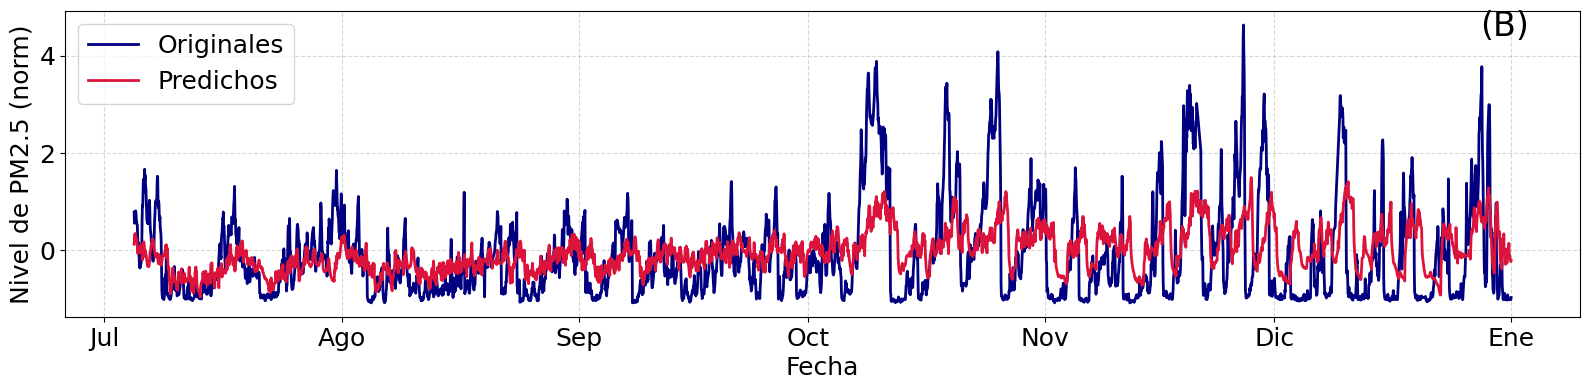

In [21]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosLSTM

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


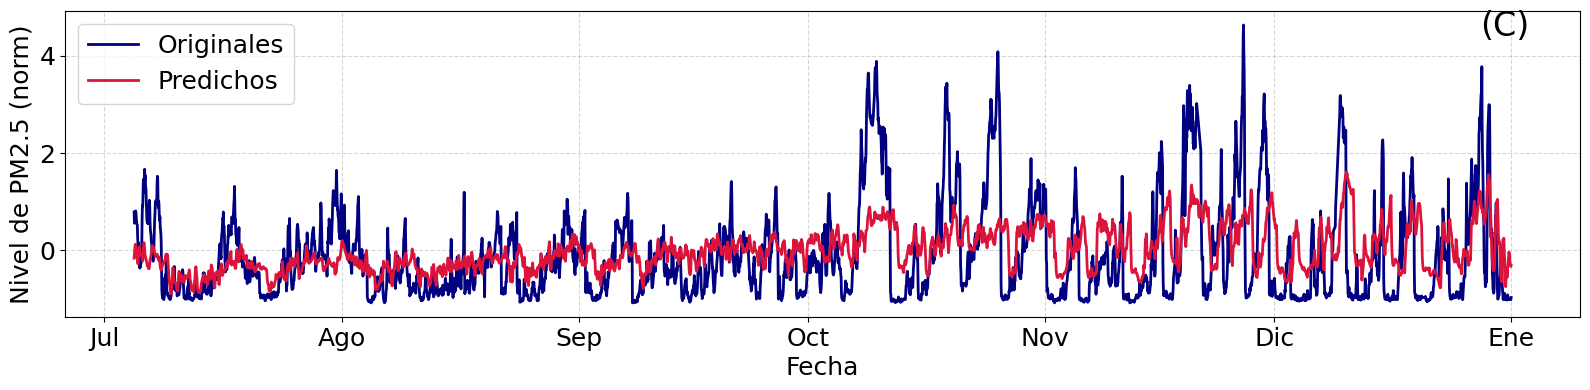

In [22]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosGRU

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


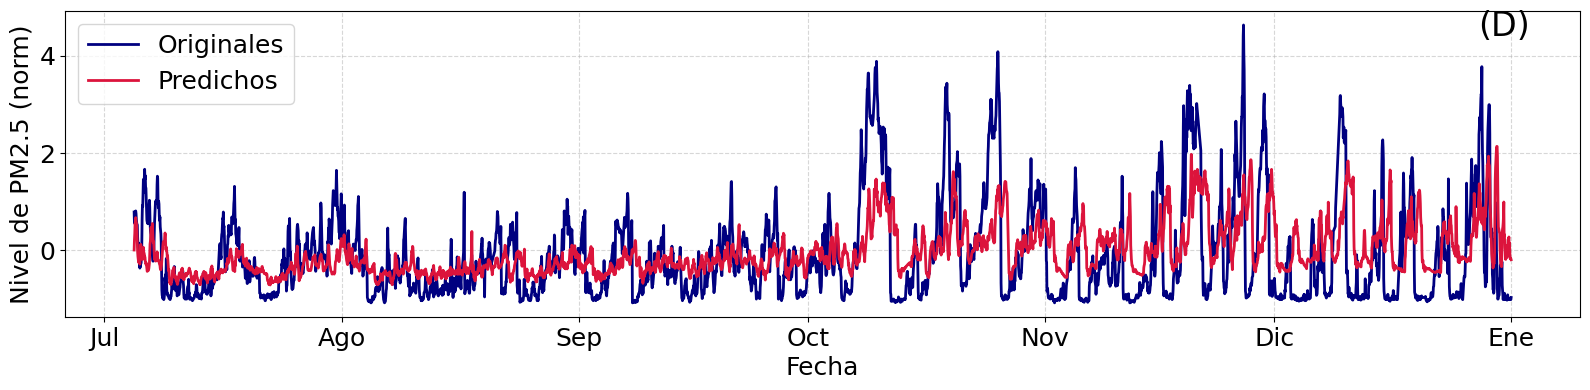

In [23]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosCross

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


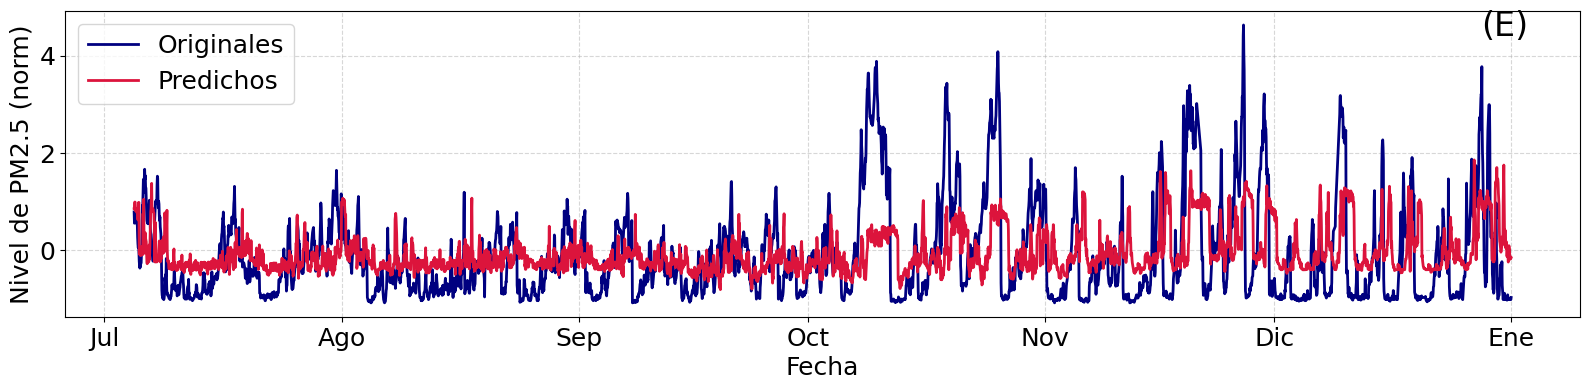

In [24]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosI

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


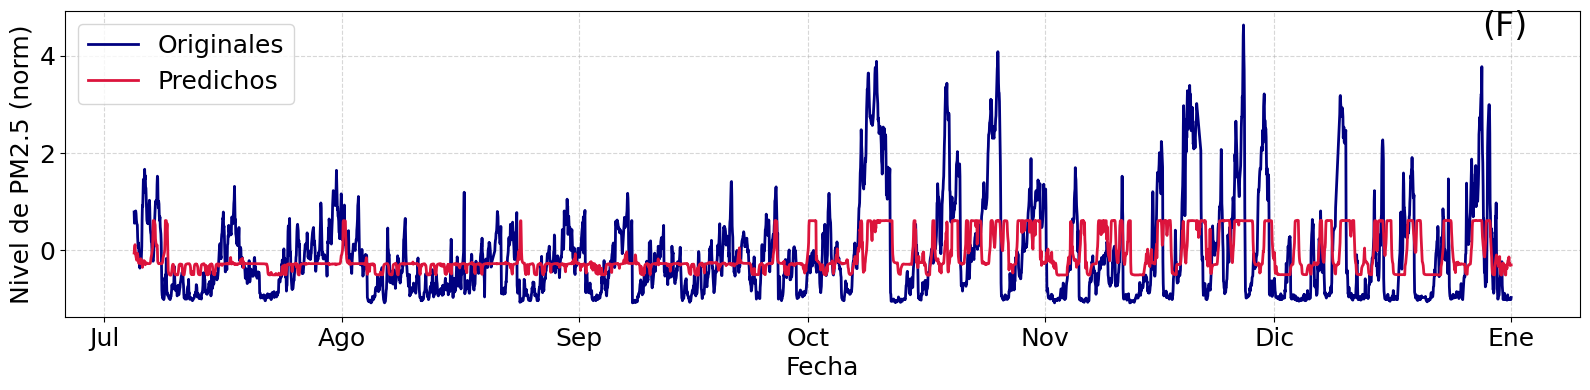

In [25]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosTFT

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


# Métricas

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [27]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7660176131149046
RMSE: 0.8752243215969862
MAE: 0.6571709926747027
SMAPE: 1.254660656460919
IA: 0.3908153095108856


In [28]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.783548716683999
RMSE: 0.885182871888063
MAE: 0.6672286367272242
SMAPE: 1.2738709134804578
IA: 0.3732512003142142


In [29]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7871303888028267
RMSE: 0.8872036907062699
MAE: 0.6712551196964907
SMAPE: 1.2721830915350378
IA: 0.3765506343144973


In [30]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8007289895997681
RMSE: 0.8948346157809096
MAE: 0.6646046369816978
SMAPE: 1.1995238381132876
IA: 0.39362850439271


In [31]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8767877262226488
RMSE: 0.9363694389623407
MAE: 0.7011299528863351
SMAPE: 1.2614137527159504
IA: 0.3266558690879705


In [32]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7846470229479046
RMSE: 0.8858030384616574
MAE: 0.6659438072882508
SMAPE: 1.1723894429385187
IA: 0.3608116079798993


# Pruebas de significación

In [33]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [34]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT:", p)


MLP: 1.2563858040340123e-12
LSTM: 6.435299708079358e-12
GRU: 5.2964725988263356e-12
Cross: 4.050982425288674e-10
iTransf: 4.506424000197969e-09
TFT: 2.4775634081506803e-08


In [35]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

6.297506921565442e-13


In [36]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.20831,1.00000,0.83323
1,MLP vs GRU,0.02604,0.39053,0.15621
2,MLP vs Crossformer,0.00418,0.06270,0.03059
3,MLP vs iTransformer,0.25509,1.00000,0.83323
4,MLP vs TFT,0.00000,0.00000,0.00000
5,LSTM vs GRU,0.00006,0.00089,0.00059
6,LSTM vs Crossformer,0.00146,0.02185,0.01311
7,LSTM vs iTransformer,0.21808,1.00000,0.83323
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00003,0.00042,0.00030
